In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)
%matplotlib inline

In [2]:
import os
print (os.getcwd())
print (os.listdir())

C:\Users\BIDISHA\Modulation_classification
['.ipynb_checkpoints', 'Modulation classification.ipynb', 'Untitled.ipynb']


In [3]:
import pandas as pd
import os
import pickle

DATA_PATH = r"C:\Users\BIDISHA\Downloads\RML2016.10a\RML2016.10a_dict_optimized.pkl"  # update this path if needed

with open(DATA_PATH, 'rb') as f:
    Xd = pickle.load(f, encoding='latin-1')

mods = sorted(set(k[0] for k in Xd.keys()))
snr_levels = sorted(set(k[1] for k in Xd.keys()))
label_map = {m: i for i, m in enumerate(mods)}
inv_label_map = {i: m for m, i in label_map.items()}

print("Modulation classes:", mods)
print("SNR levels (dB):", snr_levels)
print("Number of (mod, snr) pairs:", len(Xd))

Modulation classes: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNR levels (dB): [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Number of (mod, snr) pairs: 220


In [4]:
X, y, snr_list = [], [], []
for (mod, snr), arr in Xd.items():
    X.append(arr)
    y.extend([label_map[mod]] * arr.shape[0])
    snr_list.extend([snr] * arr.shape[0])

X = np.vstack(X).astype(np.float32)   # shape: (220000, 2, 128)
y = np.array(y)
snr_list = np.array(snr_list)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Total samples:", len(y))

X shape: (220000, 2, 128)
y shape: (220000,)
Total samples: 220000


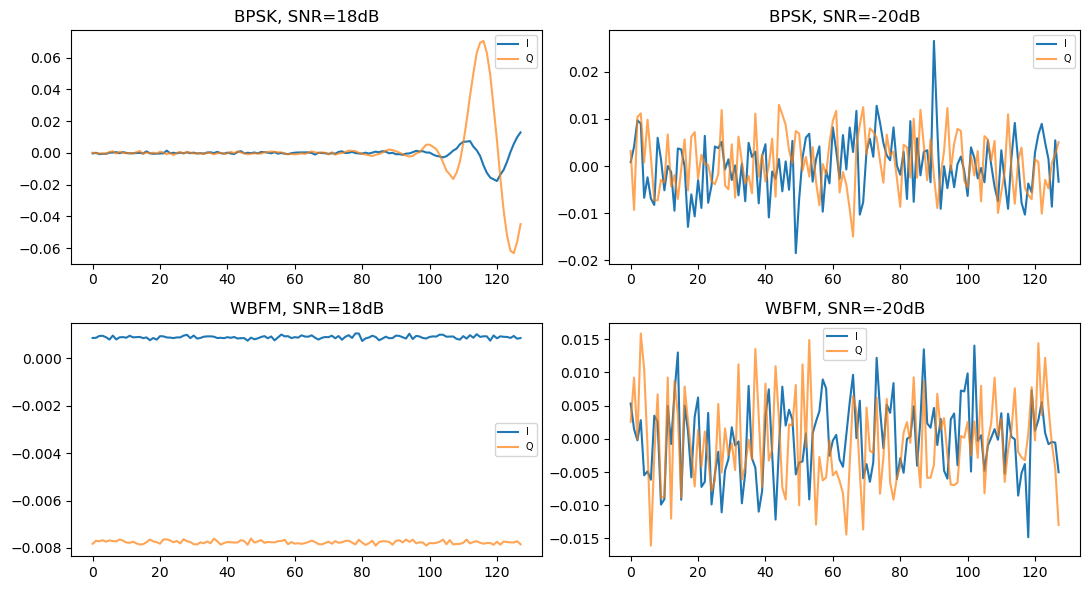

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
examples = [("BPSK", 18), ("BPSK", -20), ("WBFM", 18), ("WBFM", -20)]
for ax, (mod, snr) in zip(axes.flat, examples):
    sig = Xd[(mod, snr)][0]  # first example, shape (2, 128)
    ax.plot(sig[0], label='I')
    ax.plot(sig[1], label='Q', alpha=0.7)
    ax.set_title(f"{mod}, SNR={snr}dB")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

In [6]:
X_norm = (X - X.mean(axis=2, keepdims=True)) / (X.std(axis=2, keepdims=True) + 1e-8)

X_train, X_test, y_train, y_test, snr_train, snr_test = train_test_split(
    X_norm, y, snr_list, test_size=0.25, random_state=42, stratify=y
)

# Reshape for Conv1D: (samples, timesteps, channels=2 for I/Q)
X_train_c = np.transpose(X_train, (0, 2, 1))
X_test_c = np.transpose(X_test, (0, 2, 1))

print("Train shape:", X_train_c.shape, " Test shape:", X_test_c.shape)

Train shape: (165000, 128, 2)  Test shape: (55000, 128, 2)


In [7]:
N = X_train_c.shape[1]   # 128
n_classes = len(mods)     # 11

model = keras.Sequential([
    layers.Input(shape=(N, 2)),
    layers.Conv1D(64, 8, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.Conv1D(64, 5, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, 3, activation='relu', padding='same'),
    layers.GlobalAveragePooling1D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(n_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 128, 64)             │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 64, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 64, 64)              │          20,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 32, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 32, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 11)                  │           1,419 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 64,267 (251.04 KB)

 Trainable params: 64,267 (251.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Optional: for a faster test run, uncomment to train on a random subset first
# idx = np.random.choice(len(X_train_c), 30000, replace=False)
# X_train_c, y_train = X_train_c[idx], y_train[idx]

history = model.fit(
    X_train_c, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=256,
    verbose=2
)

Epoch 1/20
581/581 - 24s - 41ms/step - accuracy: 0.2909 - loss: 1.8431 - val_accuracy: 0.3447 - val_loss: 1.6709
Epoch 2/20
581/581 - 40s - 69ms/step - accuracy: 0.3445 - loss: 1.6693 - val_accuracy: 0.3614 - val_loss: 1.6182
Epoch 3/20
581/581 - 21s - 36ms/step - accuracy: 0.3695 - loss: 1.6220 - val_accuracy: 0.3897 - val_loss: 1.5786
Epoch 4/20
581/581 - 21s - 36ms/step - accuracy: 0.3976 - loss: 1.5665 - val_accuracy: 0.4167 - val_loss: 1.5136
Epoch 5/20
581/581 - 21s - 35ms/step - accuracy: 0.4174 - loss: 1.5198 - val_accuracy: 0.4275 - val_loss: 1.4837
Epoch 6/20
581/581 - 21s - 36ms/step - accuracy: 0.4273 - loss: 1.4951 - val_accuracy: 0.4435 - val_loss: 1.4512
Epoch 7/20
581/581 - 21s - 36ms/step - accuracy: 0.4348 - loss: 1.4752 - val_accuracy: 0.4505 - val_loss: 1.4318
Epoch 8/20
581/581 - 22s - 37ms/step - accuracy: 0.4417 - loss: 1.4571 - val_accuracy: 0.4579 - val_loss: 1.4133
Epoch 9/20
581/581 - 21s - 36ms/step - accuracy: 0.4487 - loss: 1.4402 - val_accuracy: 0.4649 - 

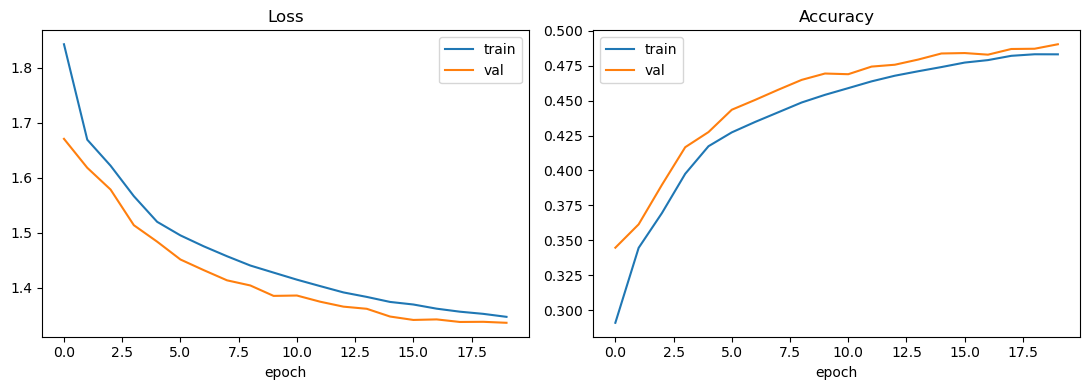

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

In [10]:
test_loss, test_acc = model.evaluate(X_test_c, y_test, verbose=0)
print(f"Overall test accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(X_test_c, verbose=0, batch_size=512), axis=1)
print()
print(classification_report(y_test, y_pred, target_names=mods))

Overall test accuracy: 0.4910

              precision    recall  f1-score   support

        8PSK       0.55      0.52      0.53      5000
      AM-DSB       0.19      0.19      0.19      5000
      AM-SSB       0.22      0.79      0.34      5000
        BPSK       0.88      0.57      0.69      5000
       CPFSK       0.86      0.59      0.70      5000
        GFSK       0.83      0.60      0.70      5000
        PAM4       0.81      0.70      0.75      5000
       QAM16       0.19      0.02      0.03      5000
       QAM64       0.49      0.72      0.59      5000
        QPSK       0.80      0.50      0.62      5000
        WBFM       0.67      0.20      0.31      5000

    accuracy                           0.49     55000
   macro avg       0.59      0.49      0.50     55000
weighted avg       0.59      0.49      0.50     55000



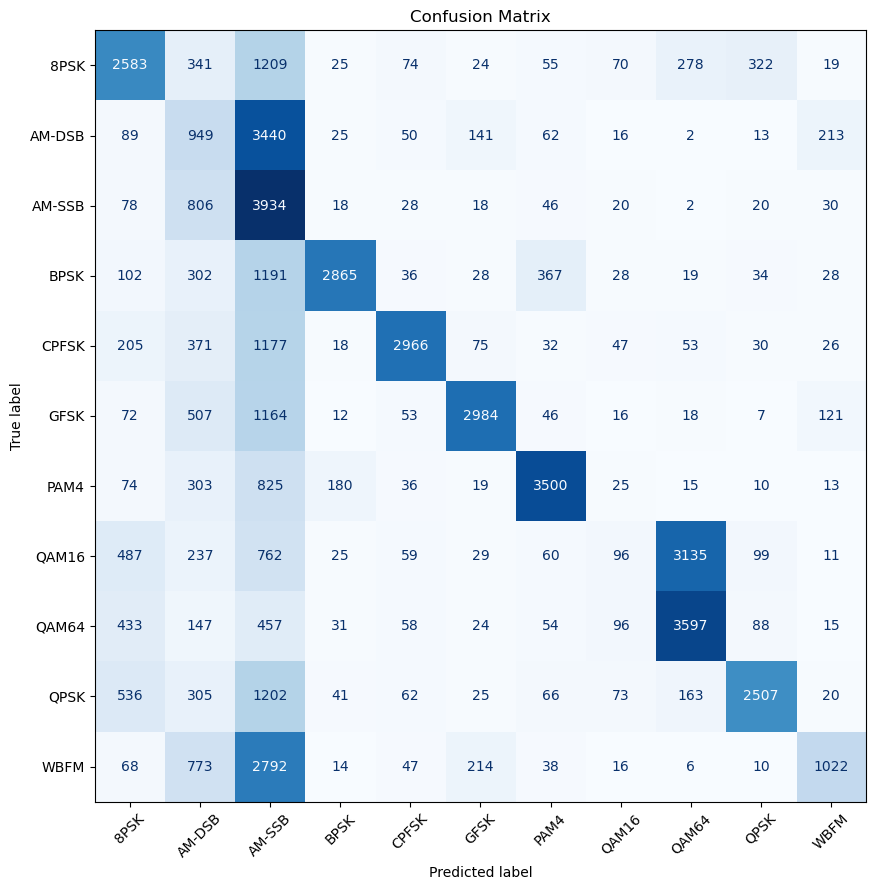

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mods)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

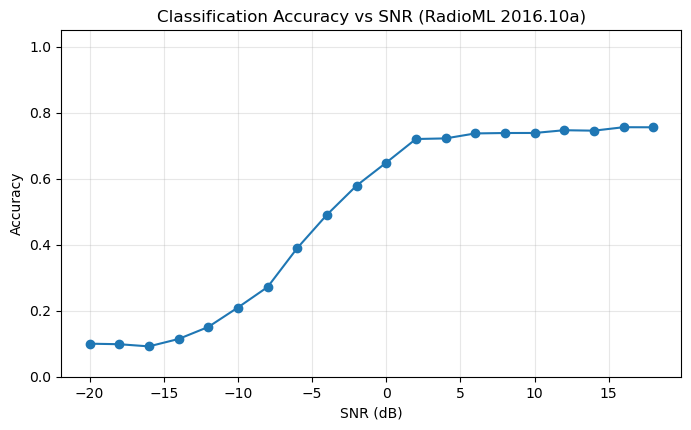

SNR  -20 dB -> accuracy 0.100
SNR  -18 dB -> accuracy 0.098
SNR  -16 dB -> accuracy 0.092
SNR  -14 dB -> accuracy 0.114
SNR  -12 dB -> accuracy 0.151
SNR  -10 dB -> accuracy 0.210
SNR   -8 dB -> accuracy 0.272
SNR   -6 dB -> accuracy 0.390
SNR   -4 dB -> accuracy 0.491
SNR   -2 dB -> accuracy 0.579
SNR    0 dB -> accuracy 0.649
SNR    2 dB -> accuracy 0.720
SNR    4 dB -> accuracy 0.722
SNR    6 dB -> accuracy 0.737
SNR    8 dB -> accuracy 0.739
SNR   10 dB -> accuracy 0.739
SNR   12 dB -> accuracy 0.747
SNR   14 dB -> accuracy 0.746
SNR   16 dB -> accuracy 0.756
SNR   18 dB -> accuracy 0.756


In [12]:
acc_per_snr = {}
for snr in snr_levels:
    mask = snr_test == snr
    if mask.sum() == 0:
        continue
    acc = (y_pred[mask] == y_test[mask]).mean()
    acc_per_snr[snr] = acc

plt.figure(figsize=(8, 4.5))
plt.plot(list(acc_per_snr.keys()), list(acc_per_snr.values()), marker='o')
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("Classification Accuracy vs SNR (RadioML 2016.10a)")
plt.grid(alpha=0.3)
plt.ylim(0, 1.05)
plt.show()

for snr, acc in acc_per_snr.items():
    print(f"SNR {snr:>4} dB -> accuracy {acc:.3f}")

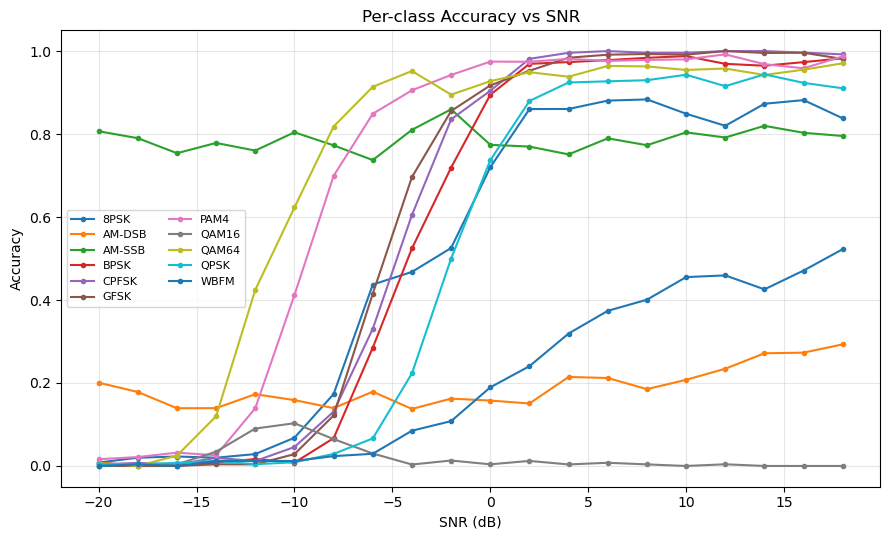

In [13]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for mod, label in label_map.items():
    accs = []
    for snr in snr_levels:
        mask = (snr_test == snr) & (y_test == label)
        if mask.sum() == 0:
            accs.append(np.nan)
            continue
        accs.append((y_pred[mask] == y_test[mask]).mean())
    ax.plot(snr_levels, accs, marker='o', markersize=3, label=mod)
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Accuracy")
ax.set_title("Per-class Accuracy vs SNR")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()